## Setup

**Test date: 1.5.2026**

**CPU**: AMD Ryzen 9 7950X 16-Core Processor

**RAM**: 128GB DDR5 G-Skill Trident Z5

**GPU**: NVIDIA RTX 4090

Running on **Ollama v0.21.0** and **Open WebUI v0.9.2** as the interface.

**Gemma4:26b (MoE)** was tasked with generating a **couch** using the **SPOMSO** package. Claude was provided with the [spomso_sdf_guide](./guides/spomso_sdf_guide.md) file and the following prompt:

*Read through the attached .md file. It contains a guide how to use the Python package SPOMSO. I want you to design a couch using this Python package. As the output I want some code that I would run and it would output the point cloud of the object and some figures. Make sure that the resulting plots show true proportions of the object. Everything else I leave up to you. Good luck and if you have any questions feel free to ask.*

## Response:

To design a couch using the SPOMSO package, we can combine various 3D primitives like `Box` and `Cylinder`, apply `rounding` to give them a soft, cushioned appearance, and use `CombineGeometry` to unite the parts [1].

Below is a complete Python script. It defines a couch consisting of a seat, a backrest, two armrests, and two plush cushions. The script generates the surface point cloud, saves it as a `.npy` file, and produces two cross-sectional views (Side and Front) that maintain true physical proportions [1].




Successfully saved 134,790 surface points to 'couch_surface_cloud.npy'


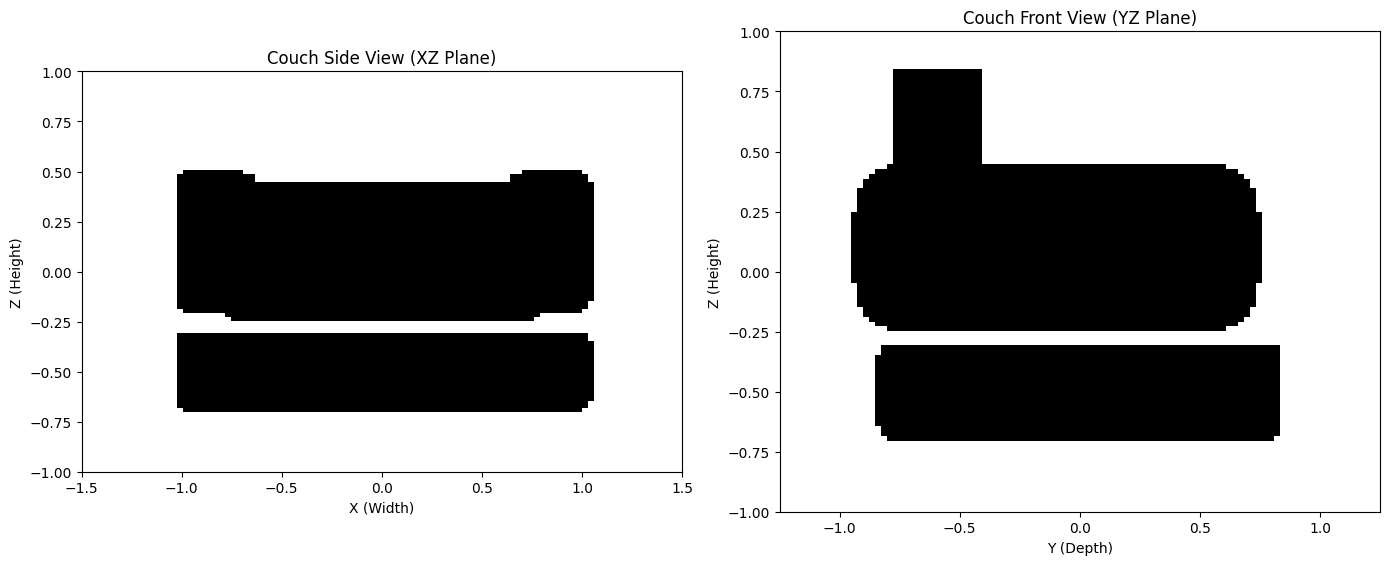

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spomso.cores.helper_functions import generate_grid, smarter_reshape
from spomso.cores.post_processing import hard_binarization
from spomso.cores.geom_3d import Box
from spomso.cores.combine import CombineGeometry

# 1. Setup the Coordinate Grid [1]
# We define a bounding box large enough to contain our couch
CO_SIZE       = (3.0, 2.5, 2.0)   # (x, y, z) extent
CO_RESOLUTION = (100, 100, 100)   # Grid resolution
coor, co_res_new = generate_grid(CO_SIZE, CO_RESOLUTION)

# 2. Define the Couch Geometry [1]
# --- The Main Seat Base ---
seat = Box(2.0, 1.6, 0.3)
seat.rounding(0.05)
seat.move((0.0, 0.0, -0.5))

# --- The Backrest ---
backrest = Box(2.0, 0.3, 1.0)
backrest.rounding(0.05)
backrest.move((0.0, -0.6, 0.3))

# --- The Armrests ---
arm_left = Box(0.3, 1.6, 0.6)
arm_left.rounding(0.05)
arm_left.move((-0.85, -0.6, 0.15))

arm_right = Box(0.3, 1.6, 0.6)
arm_right.rounding(0.05)
arm_right.move((0.85, -0.6, 0.15))

# --- Plush Cushions (using heavy rounding for a soft look) [1] ---
cushion_1 = Box(0.8, 1.3, 0.3)
cushion_1.rounding(0.2)
cushiment_1_pos = (0.3, -0.1, 0.1)
cushion_1.move(cushiment_1_pos)

cushion_2 = Box(0.8, 1.3, 0.3)
cushion_2.rounding(0.2)
cushion_2_pos = (-0.3, -0.1, 0.1)
cushion_2.move(cushion_2_pos)

# 3. Combine all parts into a single object [1]
couch_union = CombineGeometry("UNION")
couch = couch_union.combine(
    seat, backrest, arm_left, arm_right, cushion_1, cushion_2
)

# 4. Evaluate the SDF and create a binary volume [1]
sdf_values = couch.create(coor)
binary_flat = hard_binarization(sdf_values, 0)
binary_3d = smarter_reshape(binary_flat, CO_RESOLUTION)

# 5. Extract Surface Point Cloud [1]
# We identify points where the SDF is very close to the surface (zero)
dx = CO_SIZE[0] / CO_RESOLUTION[0]
surface_mask = np.abs(sdf_values) < dx * 1.5
surface_pts = coor[:, surface_mask].T  # shape (N_surface, 3)

# Save the point cloud
np.save("couch_surface_cloud.npy", surface_pts)
print(f"Successfully saved {surface_pts.shape[0]:,} surface points to 'couch_surface_cloud.npy'")

# 6. Visualization [1]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define the extent for correct proportions in plots [1]
# The extent must match the physical dimensions of the grid
extent_x = (-CO_SIZE[0]/2, CO_SIZE[0]/2)
extent_y = (-CO_SIZE[1]/2, CO_SIZE[1]/2)
extent_z = (-CO_SIZE[2]/2, CO_SIZE[2]/2)

# --- Side View (XZ Plane) ---
# Looking through the middle of the Y axis
axes[0].imshow(
    binary_3d[:, CO_RESOLUTION[1]//2, :].T,
    cmap="Greys", origin="lower",
    extent=(extent_x[0], extent_x[1], extent_z[0], extent_z[1])
)
axes[0].set_title("Couch Side View (XZ Plane)")
axes[0].set_xlabel("X (Width)")
axes[0].set_ylabel("Z (Height)")

# --- Front View (YZ Plane) ---
# Looking through the middle of the X axis
axes[1].imshow(
    binary_3d[CO_RESOLUTION[0]//2, :, :].T,
    cmap="Greys", origin="lower",
    extent=(extent_y[0], extent_y[1], extent_z[0], extent_z[1])
)
axes[1].set_title("Couch Front View (YZ Plane)")
axes[1].set_xlabel("Y (Depth)")
axes[1].set_ylabel("Z (Height)")

plt.tight_layout()
plt.show()

### How this code works:
1.  **Geometry Design**: I used `Box` primitives for the structural elements (seat, back, arms) and applied `rounding` to soften the edges [1]. To add "fluffiness," I created two additional boxes with a much higher rounding radius to simulate cushions [1].
2.  **True Proportions**: By calculating the `extent` using the `CO_SIZE` values, the `matplotlib` plots accurately represent the physical scale of the couch [1].
3.  **Point Cloud Extraction**: The code uses a threshold based on the voxel size (`dx`) to capture only the points at the zero level-set of the SDF, effectively extracting the "skin" of the couch [1].
4.  **Output**:
    *   **File**: A file named `couch_surface_cloud.npy` containing the 3D coordinates of the surface.
    *   **Figures**: Two 2D cross-sections showing the couch from the side and the front.

**End response**

**Approximate time:** 25s

## Validation

The entire **object** can be visualized with the code below:

In [ ]:
import plotly.graph_objects as go
fig = go.Figure(data=go.Volume(
    x=coor[0],
    y=coor[1],
    z=coor[2],
    value=binary_flat,
    isomin=0.9,
    isomax=1,
    opacity=1,
    surface_count=2,
))
fig.show()